# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import cupy as cp
import matplotlib.pyplot as plt
import time

In [5]:
#frank2d
from frank2d_gpu.frank2d_gpu import Frank2D
from frank2d_gpu.geometry import Geometry
from frank2d_gpu.fourier2d_gpu import FourierTransform2D
from frank2d_gpu.process_vis_gpu import Gridding
from frank2d_gpu.plot_gpu import Plot
from frank2d_gpu.constants import rad_to_arcsec, deg_to_rad
from frank2d_gpu.posterior_optimization_gpu import MAPEstimator

In [6]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2, 'disk_name': 'AS209'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88, 'disk_name': 'Elias27'}

data = Elias27

# UVtable
dir = "../../data/uvtable/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"


# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

geom = Geometry(inc, pa, dra, ddec)

# Load data
file = cp.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + 1j*Im
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

In [7]:
mempool = cp.get_default_memory_pool()
mempool.free_all_blocks()

# Opcional: Si usas pinned memory (memoria paginada CPU-GPU)
pinned_mempool = cp.get_default_pinned_memory_pool()
pinned_mempool.free_all_blocks()

## Frank2d params

In [8]:
q = cp.hypot(uvtable['u'], uvtable['v'])
q_min = cp.min(q)
q_max = cp.max(q)

Rmax = 2*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 1113
Rmax = 3.76


### Run 

In [9]:
best_N50_AS209 = {'m': -2.2478888378636794, 'c': 241548327.67926273, 'l': 37853.96840857266} # 18m12.2s
best_N50_Elias27 = {'m': -3.6400081642338615, 'c': 2.4931604784432084e+16, 'l': 57490.1215238161} #27m59s

In [10]:
best = best_N50_Elias27

In [11]:
frank2d = Frank2D(N, Rmax)

In [12]:
frank2d.process_vis(uvtable)

===>  Setting gridded data...


In [13]:
frank2d.fit(kernel_params = best, rtol = 1e-10, precond_type = 'ilu') # 1m14.7s

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -3.6400081642338615, 'c': 2.4931604784432084e+16, 'l': 57490.1215238161}
===>  Creating sparse linear system...


        +  Kernel = 0.07  min |  4.40 seconds
        !  Transferring matrix to CPU for ILU factorization...
        +   GPU->CPU & CSC = 0.00  min |  0.28 seconds
        +  ILU (on CPU) = 0.64  min |  38.21 seconds
        +  Building system = 0.72  min |  43.04 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 10/50000 [00:01<1:37:39,  8.53 iterations/s]


            +  BiCGStab = 0.02  min |  1.18 seconds
          + CGM converged?   True
          + Fit correctly?    ✔✔✔✔✔✔✔ Sucess..
{'CGM_converged': True,
 'Fit_correctly': array(True),
 'convergence_by': 'norm of r',
 'final_tol': 0.0,
 'iterations': 10,
 'maxiter': 50000,
 'preconditioner_method': 'ilu',
 'rtol': 1e-10}
Building full visibility model...
--> times building full visibility model = 0.11  min |  6.80 seconds


### Run several $N_{opt}$

**Simulated data**
* times_opt =  [9.326814635594685, 16.271777180830636, 29.956044511000314, 62.58505432208379, 239.67634643713635] # min
* times_best = [28.13317108154297, 32.60010886192322, 26.65605092048645, 19.283380031585693, 53.582895040512085] # seg
* Qmax_N50, Qmax_N60, Qmax_N70, Qmax_N80, Qmax_N100 = [1823140.5402181398, 2187768.648261768, 2552396.756305396, 2917024.8643490244, 3646281.0804362795]
* params_N50, params_N60, params_N70, params_N80, params_N100 = [{'m': -2.692877726304575, 'c': 5565999406071.04, 'l': 85344.27916739318}, {'m': -3.173339346404725, 'c': 4782311642990891.0, 'l': 83515.6290880256}, {'m': -3.5831562281230305, 'c': 1.473704358376612e+18, 'l': 81079.44744259916}, {'m': -4.572442130254884, 'c': 1.0084384650978846e+24, 'l': 68720.771036978}, {'m': -6.0445769086881205, 'c': 1.4300593860064604e+33, 'l': 80200.56804261949}]


In [13]:
N_opt = [50]

In [14]:
frank2d_objects = []

#### Load objects

In [14]:
import pickle
disc ='Simulated'

for N in N_opt:
    path = dir + disc + '_opt_Nopt_' + str(N) + '.pkl'
    with open(path, 'rb') as f:   # 'rb' = read binary
        obj = pickle.load(f)
        frank2d_objects.append(obj)

### Run

In [15]:
maps = []
frank2d_objects = []
times_opt = []

In [16]:
p0 = -1.85
m0 = -2
initial_guess = {'p': p0, 'm': m0, 'logl': 4}

In [17]:
for i in range(len(N_opt)):
    start_time = time.time()

    frank2d = Frank2D(N, Rmax)
    start_time = time.time()
    frank2d.process_vis(uvtable)
    end_time = time.time()
    print("Time to process visibilities: {:.2f} seconds".format(end_time - start_time))
    
    frank2d.search_MAP(initial_guess= initial_guess, N = N_opt[i]) 

    end_time = time.time()
    total_time = end_time - start_time
    print("xxxxxxxxxxxxxxxxxxxxxx Total time for N_opt={} : {:.2f} seconds".format(N_opt[i], total_time))

    times_opt.append(total_time)
    frank2d_objects.append(frank2d)

===>  Setting gridded data...
Time to process visibilities: 1.24 seconds
Using existing visibility data...
===>  Searching for MAP parameters...
        + Initial guess:  {'p': -1.85, 'm': -2, 'logl': 4}
Fitting the visibilities with Frank2D with 2DFT...
 + Time to preprocess the visibilities: 196.41 seconds
Setting the initial guess...
Optimizing the posterior...
 + Time to optimize the posterior: 1011.87 seconds
xxxxxxxxxxxxxxxxxxxxxx Total time for N_opt=50 : 1214.58 seconds


In [18]:
for i in frank2d_objects:
    print(i.MAP)

{'m': -3.640010718831058, 'c': 2.4932448374982884e+16, 'l': 57490.11508825995}


In [ ]:
# AS209
best_N50 = {'m': -2.2479009949531608, 'c': 241586218.69917032, 'l': 37853.91368620107} # 15m5s / 805s in optimize
best_N60 = {'m': -1.7999542331146396, 'c': 950813.2007195376, 'l': 38844.371062214064} # 27m48.1s / 1461.21 s in optimize
best_N70 = {'m': -1.3385367729609008, 'c': 2972.9541949105133, 'l': 38691.20043197729}# 114m48s / 6239.44 in optimize

#Elias27
best_N50 = {'m': -3.6400081642338615, 'c': 2.4931604784432084e+16, 'l': 57490.1215238161} #27m59s / 1011.87s in optimize

In [52]:
# save object with pickle
import pickle
dir = "../../data/exp/N_opt"
N_opts = [50, 60, 70, 80, 90, 100]
i = 2
disc = disk_name
path = dir + disc + '_optGPU_Nopt' + str(N_opts[i]) + '.pkl'
with open(path, 'wb') as f:   # 'wb' = write binary
    pickle.dump(frank2d_objects[i], f)

### Plot the stats for posterior

#### function to plot

In [25]:
def plot_MAP_estimation_results(results, results_best, N_opt, normalize = False):
    import numpy as np
    ms = results['ms']
    cs = results['cs']
    ls = results['ls']
    jDjs = results['jDjs']
    logdetDs = results['logdetDs']
    logdetSs = results['logdetSs']
    minus_log_posteriors = results['minus_log_posteriors']

    m_best = results_best['m']
    c_best = 10**results_best['logc']
    l_best = 10**results_best['logl']
    jDj_best = results_best['jDj']
    logdetD_best = results_best['logdetD']
    logdetS_best = results_best['logdetS']
    minus_log_posterior_best = results_best['minus_log_posterior']

    fig, axs = plt.subplots(3, 3, figsize=(10, 7))
    axs = axs.ravel()

    iterations = np.arange(1, len(ms) + 1)

    axs[0].plot(iterations, ms, '-', c='purple')
    axs[0].set_xlabel('Iteration')
    axs[0].axhline(  m_best, color='gray', linestyle='--',
                        label=r'$m_{best}$ =' + f'{m_best:.2e}')
    axs[0].set_ylabel('m')
    axs[0].legend(fontsize=7, loc='best')

    axs[1].plot(iterations, cs, '-', c='purple')
    axs[1].set_xlabel('Iteration')
    axs[1].axhline( c_best, color='gray', linestyle='--',
                       label=r'$c_{best}$ =' + f'{c_best:.2e}')
    axs[1].set_yscale('log')
    axs[1].set_ylabel('logc')
    axs[1].legend(fontsize=7, loc='best')

    axs[2].plot(iterations, ls, '-', c='purple')
    axs[2].set_xlabel('Iteration')
    axs[2].axhline(  l_best, color='gray', linestyle='--',
                         label=r'$l_{best}$ =' + f'{l_best:.2e}')
    axs[2].set_yscale('log')
    axs[2].set_ylabel('logl')
    axs[2].legend(fontsize=7, loc='best')

    if normalize:
        jDjs = np.abs(jDjs - jDj_best)
        axs[3].set_ylabel(r'$\|jDj- jDj_{best}\|$')
    else:
        axs[3].axhline( jDj_best, color='gray', linestyle='--',
                         label=r'$jDj_{best}$ =' + f'{jDj_best:.2e}')
        axs[3].set_ylabel('jDj')
        axs[3].legend(fontsize=7, loc='best')
    axs[3].set_xlabel('Iteration')
    axs[3].plot(iterations, jDjs, '-', c='red')

    if normalize:
        logdetDs = np.abs(logdetDs - logdetD_best)
        axs[4].set_ylabel(r'$\|log|D| - log|D|_{best}\|$')
    else:
        axs[4].axhline(
            logdetD_best, color='gray', linestyle='--',
            label=r'$log|D|_{best}$ =' + f'{logdetD_best:.2e}')
        axs[4].legend(fontsize=7, loc='best')
        axs[4].set_ylabel('log|D|')
    axs[4].plot(iterations, logdetDs, '-', c='blue')
    axs[4].set_xlabel('Iteration')

    if normalize:
        logdetSs = np.abs(logdetSs-logdetS_best)
        axs[5].set_ylabel(r'$\| log|S| - log|S|_{best}\|$')
    else:
        axs[5].axhline(  logdetS_best, color='gray', linestyle='--',
                         label=r'$log|S|_{best}$ =' + f'{logdetS_best:.2e}')
        axs[5].set_ylabel('log|S|')
        axs[5].legend(fontsize=7, loc='best')
    axs[5].plot(iterations, logdetSs, '-', c='green')
    axs[5].set_xlabel('Iteration')

    if normalize:
        minus_log_posteriors = np.abs(minus_log_posteriors - minus_log_posterior_best)
        axs[7].set_ylabel(r'$\|logP -logP_{best}\|$')
    else:
        axs[7].axhline(  minus_log_posterior_best, color='gray', linestyle='--',
                         label= r'$-logP_{best}$ =' + f'{minus_log_posterior_best:.2e}')
        axs[7].set_ylabel('-logP')
        axs[7].legend(fontsize=7, loc='best')
    axs[7].plot(iterations, minus_log_posteriors, '-', c='black')
    axs[7].set_xlabel('Iteration')

    for ax in [axs[6], axs[8]]:
        fig.delaxes(ax)
    
    #for ax in [axs[3], axs[4], axs[5], axs[7]]:
    #    ax.set_yscale('log')

    #for ax in [axs[3], axs[4], axs[5], axs[7]]:
    #    ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))

    plt.suptitle(r'MAP Estimation $N_{opt}$ = '+ str(N_opt))
    plt.tight_layout()
    plt.show()

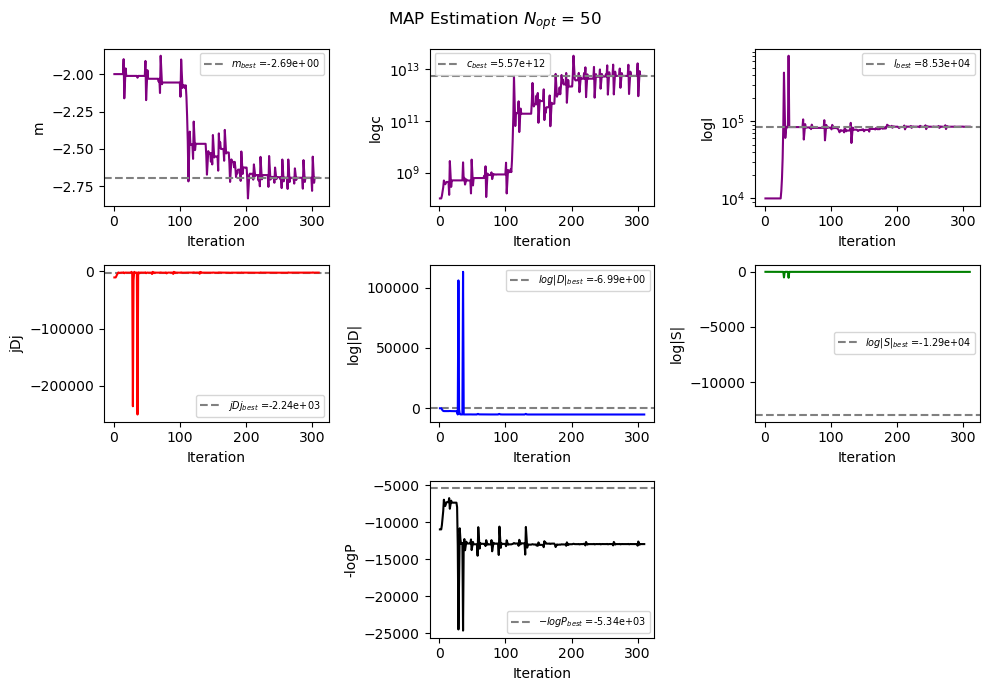

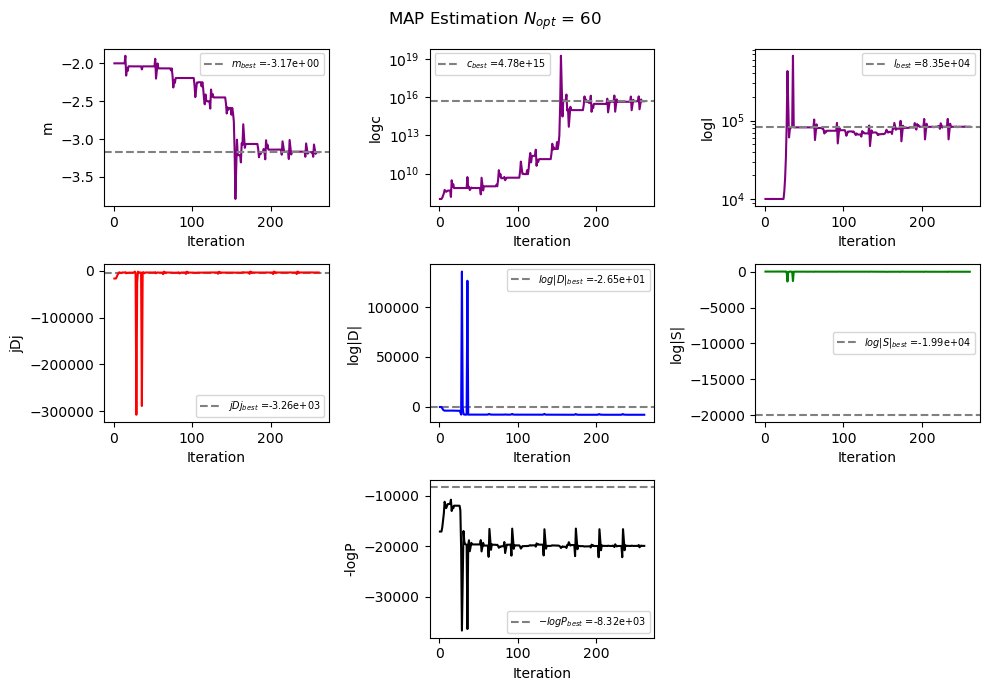

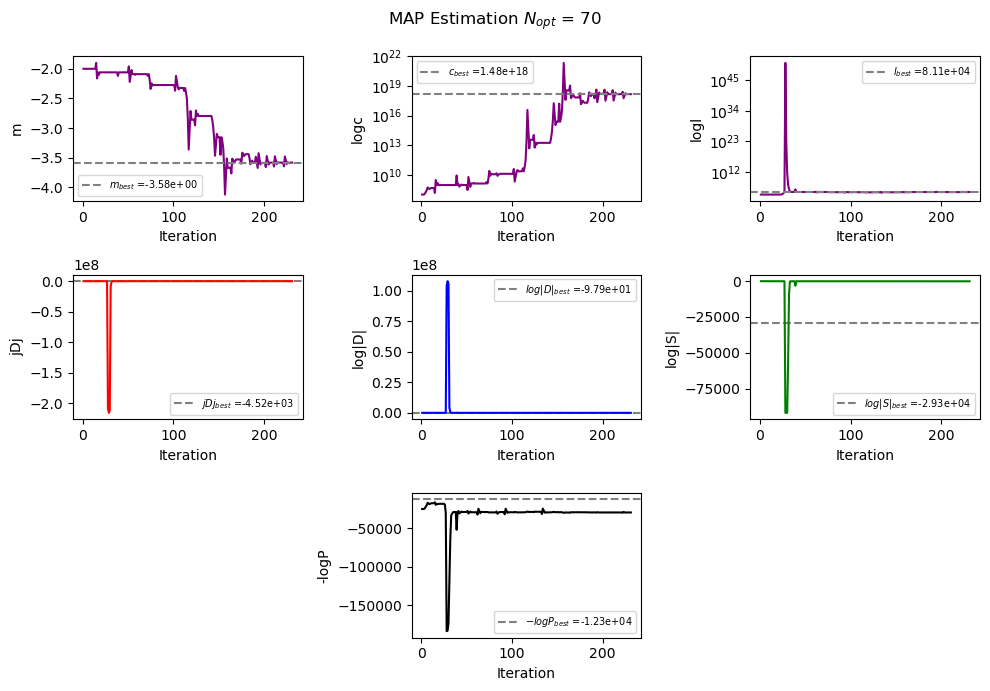

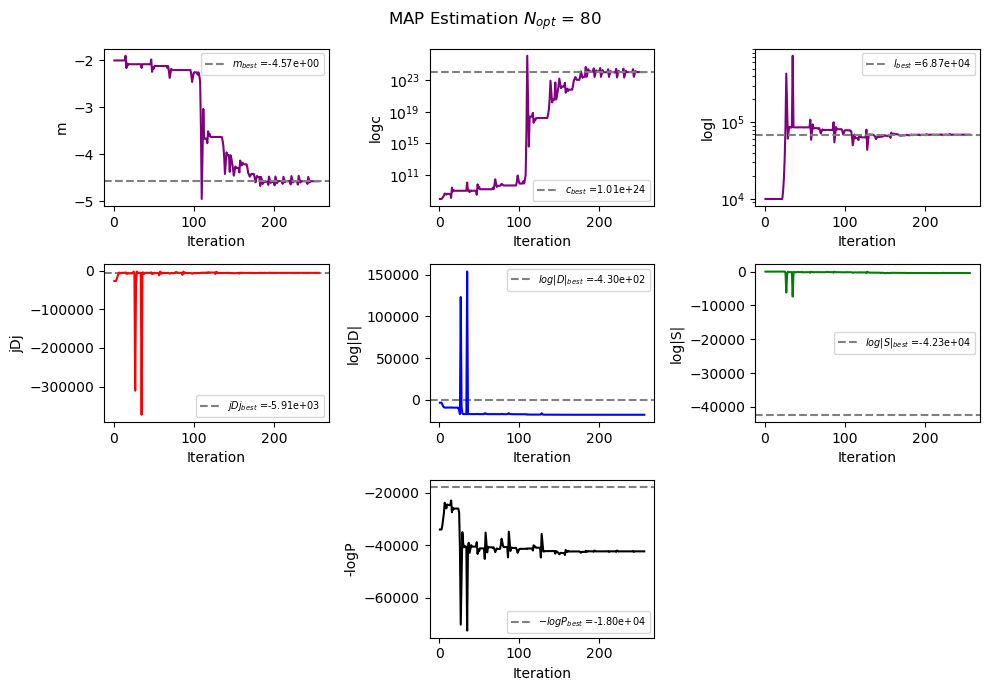

In [26]:
for i in range(0, len(N_opt)):
    frank2d_N = frank2d_objects[i]
    MAPEs_N = frank2d_N.MAPEstimator

    MAP_N = frank2d_N.MAP
    m_best_N = MAP_N['m']
    l_best_N = MAP_N['l']
    c_best_N = MAP_N['c']
    logl_best_N = cp.log10(l_best_N).get()
    logc_best_N = cp.log10(c_best_N).get()
    best_N = {
        'm': m_best_N,
        'logl': logl_best_N,
        'logc': logc_best_N
    }

    ms_N =  MAPEs_N._ms
    cs_N = MAPEs_N._cs
    ls_N = MAPEs_N._ls
    jDjs_N = MAPEs_N._jDjs
    logdetDs_N = MAPEs_N._logdetDs
    logdetSs_N = MAPEs_N._logdetSs
    minus_log_posteriors_N = MAPEs_N._minus_log_posteriors

    results_N = {
        'ms': ms_N,
        'cs': cs_N,
        'ls': ls_N,
        'jDjs': jDjs_N,
        'logdetDs': logdetDs_N,
        'logdetSs': logdetSs_N,
        'minus_log_posteriors': minus_log_posteriors_N,
    }

    GP_N =  MAPEs_N.GaussianModel
    p0, jDj0, logdetS0, logdetD0 = MAPEs_N._p0
    best_minus_log_posteriors_N = GP_N.minus_log_posterior(best_N) - p0
    best_jDj_N, best_logdetD_N, best_logdetS_N = GP_N._jDj - jDj0, GP_N._logdetD-logdetD0, GP_N._logdetS-logdetS0
    
    results_best_N = {
        'm': m_best_N,
        'logl': logl_best_N,
        'logc': logc_best_N,
        'minus_log_posterior': best_minus_log_posteriors_N,
        'jDj': best_jDj_N,
        'logdetD': best_logdetD_N,
        'logdetS': best_logdetS_N,
    }

    plot_MAP_estimation_results(results_N, results_best_N, N_opt[i], normalize = False) 


### Maximum baseline for each N_opt

In [55]:
for i in range(0, len(N_opt)):
    frank2d_N = frank2d_objects[i]
    MAPEs_N = frank2d_N.MAPEstimator
    GP_N =  MAPEs_N.GaussianModel
    DFT_N = GP_N._2DFT
    print( DFT_N.Qmax)


1823140.5402181398
2187768.648261768
2552396.756305396
2917024.8643490244
3646281.0804362795


### $\ell$

In [68]:
l_array = []
for i in maps:
    l_array.append(i['l'])

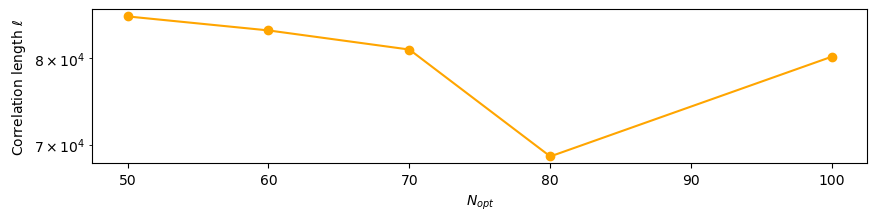

In [72]:
plt.figure(figsize=(10,2))
plt.plot(N_opt, l_array, 'o-', color= 'orange')
plt.yscale('log')
plt.xlabel(r'$N_{opt}$')
plt.ylabel(r'Correlation length $\ell$')
plt.show()


## Plot the best

In [59]:
times_best2 = []

In [60]:
frank2d_objects_best = []

In [65]:
for i in range(len(frank2d_objects)):
    start = time.time()
    frank2d = Frank2D(500, rout)
    maps_i = maps[i]
    frank2d.fit(data = uvtable, kernel_params = maps_i, rtol = 1e-10)

    end = time.time()
    total_time = end - start
    times_best2.append(total_time)
    frank2d_objects_best.append(frank2d)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={maps_i} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.692877726304575, 'c': 5565999406071.04, 'l': 85344.27916739318}
===>  Creating sparse linear system...
        + time kernel = 0.05  min |  2.74 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.05  min |  2.83 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-10
         + final tolerance :  0.012212677737961327
                        .... iteration:  0
                              -> actual tol  1.22e+08  versus  1.22e-02
                        .... iteration:  1
                              -> actual tol  1.83e+07  versus  1.22e-02
                        .... iteration:  2
                              -> actual tol  1.80e+07  versus  1.22e-02
                        .... iteration:  3
                              -> actual tol  1.57e+07  versus  1.22e-02
                        .... iteration:  4
          

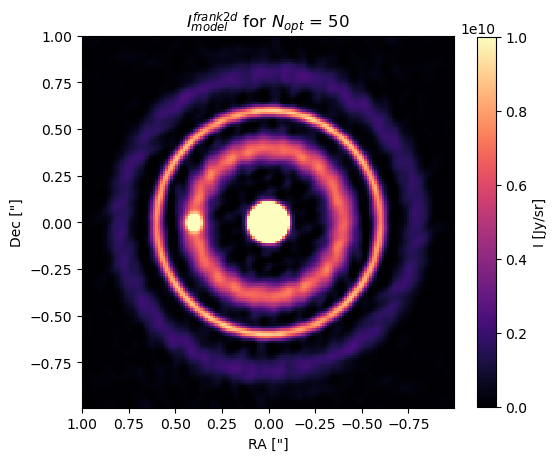

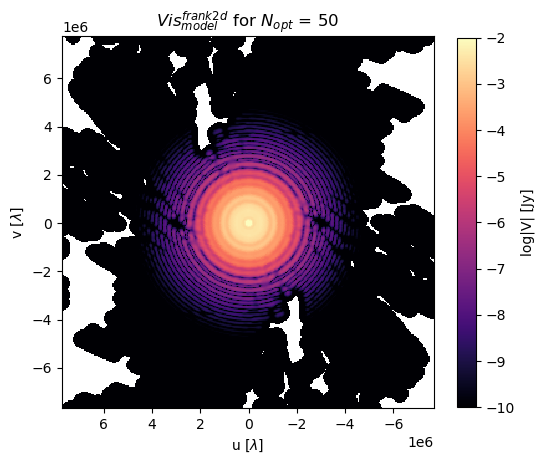

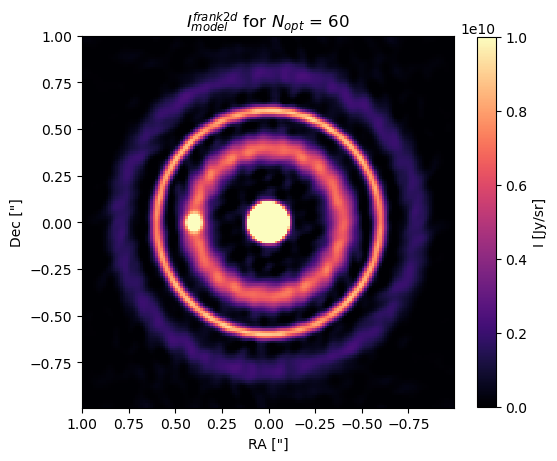

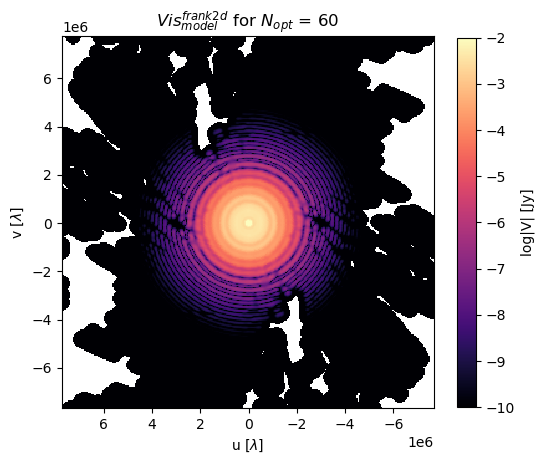

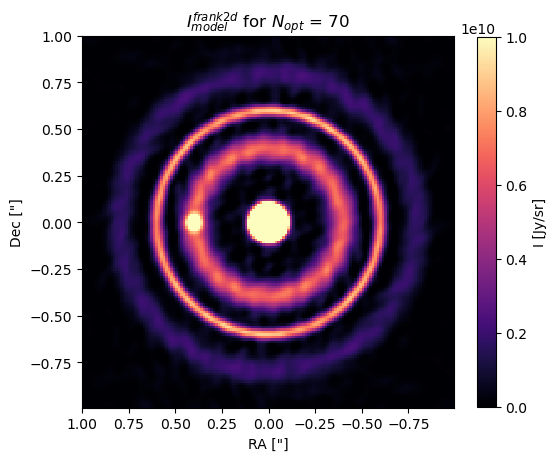

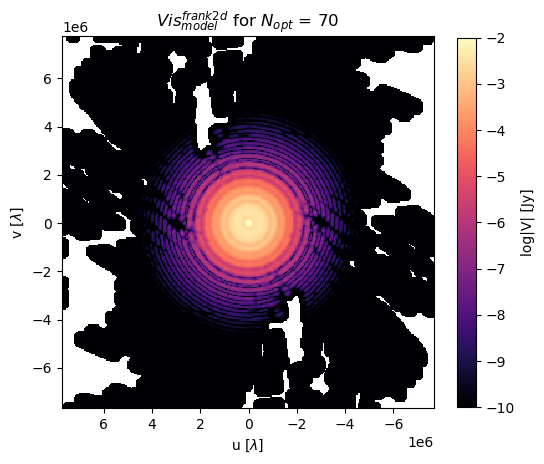

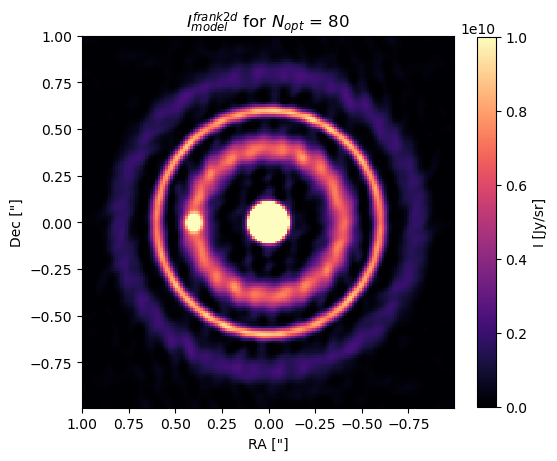

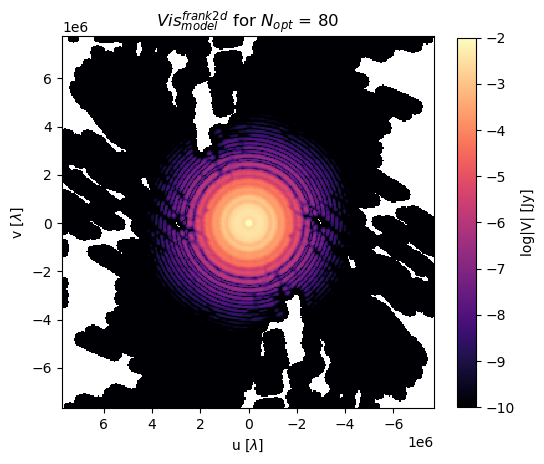

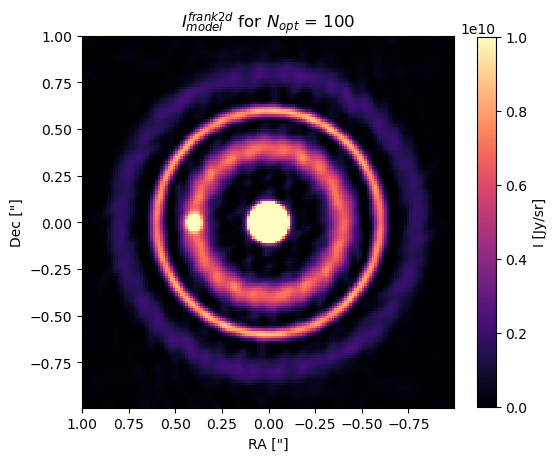

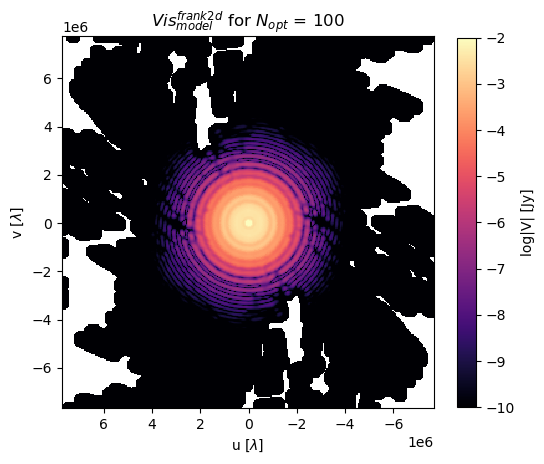

IndexError: list index out of range

In [67]:
for i in range(len(frank2d_objects_best)-1):
    Plot_ = Plot(frank2d_objects_best[i], geom)
    Plot_.intensity( vmax=1e10,  gamma = 1, zoom=2,
                     title= r'$I_{model}^{frank2d}$ for $N_{opt}$ = ' + str(N_opt[i]))
    Plot_.visibility(fig_size = 6,
                     title = r'$Vis_{model}^{frank2d}$ for $N_{opt}$ = ' + str(N_opt[i]))